# 📊 EDA – Phân Tích Hệ Thống Kinh Doanh E-Commerce

**Nội dung notebook:**
- Tổng quan dữ liệu & làm sạch
- KPI tổng hợp (doanh thu, đơn hàng, khách hàng)
- Phân tích doanh thu theo thời gian *(filter: 7 ngày / 30 ngày / tháng / năm — dùng khi build frontend)*
- Top 10 sản phẩm & danh mục
- Top 10 địa lý (bang / thành phố)
- Hiệu suất nhân viên / seller
- Heatmap hành vi mua sắm (giờ × thứ)

## 1. Import Thư Viện & Load Dữ Liệu

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

COLOR_PRIMARY = '#4C72B0'
COLOR_SUCCESS = '#55A868'
COLOR_DANGER  = '#C44E52'
COLOR_WARN    = '#CCB974'

# ── Load ───────────────────────────────────────────────────
df_raw = pd.read_csv("../data/live/sales_dashboard.csv", parse_dates=['order_purchase_timestamp'])
print(f"Load thành công: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
df_raw.head()

Load thành công: 90,916 dòng × 12 cột


,order_id,order_purchase_timestamp,price,freight_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04 21:15:19,39.99,31.67,shipped,1554a68530182680ad5c8b042c3ab563,b7d76e111c89f7ebf14761390f0f7d17,boa vista,RR,moveis_decoracao,Nội thất & Trang trí,c1488892604e4ba5cff5b4eb4d595400
1,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04 21:15:19,32.90,31.67,shipped,1554a68530182680ad5c8b042c3ab563,b7d76e111c89f7ebf14761390f0f7d17,boa vista,RR,moveis_decoracao,Nội thất & Trang trí,f293394c72c9b5fafd7023301fc21fc2
2,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,44.99,2.83,delivered,ecccfa2bb93b34a3bf033cc5d1dcdc69,830d5b7aaa3b6f1e9ad63703bec97d23,sao joaquim da barra,SP,beleza_saude,Sức khỏe & Làm đẹp,5a6b04657a4c5ee34285d1e4619a96b4
3,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,29.90,15.56,delivered,522620dcb18a6b31cd7bdf73665113a9,32ea3bdedab835c3aa6cb68ce66565ef,sao paulo,SP,relogios_presentes,Đồng hồ & Quà tặng,3ae08df6bcbfe23586dd431c40bddbb7
4,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,21.90,17.19,delivered,f09b760d23495ac9a7e00d29b769007c,2f64e403852e6893ae37485d5fcacdaf,panambi,RS,esporte_lazer,Thể thao & Giải trí,fd7fd78fd3cbc1b0a6370a7909c0a629


In [46]:
print("=" * 55)
print("THÔNG TIN TỔNG QUAN (df_raw — chưa lọc)")
print("=" * 55)
print(f"Số dòng       : {df_raw.shape[0]:,}")
print(f"Số cột        : {df_raw.shape[1]}")
print(f"Thời gian     : {df_raw['order_purchase_timestamp'].min()} → {df_raw['order_purchase_timestamp'].max()}")
print(f"Số đơn hàng   : {df_raw['order_id'].nunique():,}")
print(f"Số khách hàng : {df_raw['customer_unique_id'].nunique():,}")
print(f"Số seller     : {df_raw['seller_id'].nunique():,}")
print(f"Số sản phẩm   : {df_raw['product_id'].nunique():,}")
print(f"Số danh mục   : {df_raw['Category_VN'].nunique()}")
print(f"Trạng thái đơn: {df_raw['order_status'].unique()}")
print("=" * 55)
df_raw.dtypes

THÔNG TIN TỔNG QUAN (df_raw — chưa lọc)
Số dòng       : 90,916
Số cột        : 12
Thời gian     : 2016-09-04 21:15:19 → 2018-07-15 23:59:54
Số đơn hàng   : 87,579
Số khách hàng : 84,735
Số seller     : 2,720
Số sản phẩm   : 29,158
Số danh mục   : 24
Trạng thái đơn: ['shipped' 'delivered' 'invoiced']


order_id                            object
order_purchase_timestamp    datetime64[ns]
price                              float64
freight_value                      float64
order_status                        object
seller_id                           object
customer_unique_id                  object
customer_city                       object
customer_state                      object
product_category_name               object
Category_VN                         object
product_id                          object
dtype: object

## 2. Làm Sạch & Lọc Dữ Liệu

In [47]:
# ── Chỉ giữ đơn hàng đã giao thành công ──────────────────
df = df_raw[df_raw['order_status'] == 'delivered'].copy()

print(f"Tổng dòng gốc       : {len(df_raw):,}")
print(f"Sau lọc 'delivered' : {len(df):,}  ({len(df)/len(df_raw)*100:.1f}%)")
print(f"Loại bỏ             : {len(df_raw)-len(df):,} dòng")

# ── Kiểm tra missing ──────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing values:\n", missing) if len(missing) else print("\n✅ Không có missing values")

# ── Đơn nhiều sản phẩm ────────────────────────────────────
items_per_order = df.groupby('order_id').size()
multi_item = (items_per_order > 1).sum()
print(f"\nĐơn nhiều sản phẩm : {multi_item:,} orders ({multi_item/len(items_per_order)*100:.1f}%)")
print("   → Bình thường, dataset lưu theo order-item level")

# ── Cột thời gian phụ trợ ─────────────────────────────────
df['date']    = df['order_purchase_timestamp'].dt.date
df['year']    = df['order_purchase_timestamp'].dt.year
df['month']   = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['hour']    = df['order_purchase_timestamp'].dt.hour
df['weekday'] = df['order_purchase_timestamp'].dt.day_name()

print(f"\nShape sau xử lý: {df.shape}")
df.head()

Tổng dòng gốc       : 90,916
Sau lọc 'delivered' : 89,583  (98.5%)
Loại bỏ             : 1,333 dòng

✅ Không có missing values

Đơn nhiều sản phẩm : 2,869 orders (3.3%)
   → Bình thường, dataset lưu theo order-item level

Shape sau xử lý: (89583, 17)


,order_id,order_purchase_timestamp,price,freight_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id,date,year,month,hour,weekday
2,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,44.99,2.83,delivered,ecccfa2bb93b34a3bf033cc5d1dcdc69,830d5b7aaa3b6f1e9ad63703bec97d23,sao joaquim da barra,SP,beleza_saude,Sức khỏe & Làm đẹp,5a6b04657a4c5ee34285d1e4619a96b4,2016-09-15,2016,2016-09,12,Thursday
3,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,29.90,15.56,delivered,522620dcb18a6b31cd7bdf73665113a9,32ea3bdedab835c3aa6cb68ce66565ef,sao paulo,SP,relogios_presentes,Đồng hồ & Quà tặng,3ae08df6bcbfe23586dd431c40bddbb7,2016-10-03,2016,2016-10,9,Monday
4,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,21.90,17.19,delivered,f09b760d23495ac9a7e00d29b769007c,2f64e403852e6893ae37485d5fcacdaf,panambi,RS,esporte_lazer,Thể thao & Giải trí,fd7fd78fd3cbc1b0a6370a7909c0a629,2016-10-03,2016,2016-10,16,Monday
5,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,36.49,17.24,delivered,45d33f715e24d15a6ccf5c17b3a23e3c,61db744d2f835035a5625b59350c6b63,porto alegre,RS,esporte_lazer,Thể thao & Giải trí,b72b39418216e944bb34e35f4d3ea8c7,2016-10-03,2016,2016-10,21,Monday
6,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,119.90,13.56,delivered,cca3071e3e9bb7d12640c9fbe2301306,8d3a54507421dbd2ce0a1d58046826e0,hortolandia,SP,moveis_decoracao,Nội thất & Trang trí,107177bf61755f05c604fe57e02467d6,2016-10-03,2016,2016-10,22,Monday


In [48]:
df.dtypes

order_id                            object
order_purchase_timestamp    datetime64[ns]
price                              float64
freight_value                      float64
order_status                        object
seller_id                           object
customer_unique_id                  object
customer_city                       object
customer_state                      object
product_category_name               object
Category_VN                         object
product_id                          object
date                                object
year                                 int32
month                               object
hour                                 int32
weekday                             object
dtype: object

## 3. KPI Tổng Hợp

In [50]:
# ── Tổng hợp cấp order ────────────────────────────────────
order_df = df.groupby('order_id').agg(
    total_price   = ('price',         'sum'),
    total_freight = ('freight_value', 'sum'),   # freight PER ITEM → sum đúng
    items         = ('product_id',    'count'),
    order_date    = ('order_purchase_timestamp', 'first'),
    seller_id     = ('seller_id',     'first'),
    state         = ('customer_state','first'),
    city          = ('customer_city', 'first'),
    category      = ('Category_VN',   'first'),
).reset_index()

order_df['revenue']       = order_df['total_price'] + order_df['total_freight']
order_df['freight_ratio'] = (order_df['total_freight'] / order_df['revenue'] * 100).round(1)

total_revenue   = order_df['revenue'].sum()
total_orders    = len(order_df)
total_customers = df['customer_unique_id'].nunique()
total_sellers   = df['seller_id'].nunique()
avg_order_val   = order_df['revenue'].mean()
avg_items       = order_df['items'].mean()

print("=" * 55)
print("KPI TỔNG HỢP – DELIVERED ORDERS")
print("=" * 55)
print(f"  Tổng doanh thu         : {total_revenue:,.2f}")
print(f"  Tổng đơn hàng          : {total_orders:,}")
print(f"  Khách hàng unique      : {total_customers:,}")
print(f"  Sellers                : {total_sellers:,}")
print(f"  AOV (TB / đơn)         : {avg_order_val:,.2f}")
print(f"  TB sản phẩm / đơn      : {avg_items:.1f}")

KPI TỔNG HỢP – DELIVERED ORDERS
  Tổng doanh thu         : 12,876,192.20
  Tổng đơn hàng          : 86,277
  Khách hàng unique      : 83,506
  Sellers                : 2,705
  AOV (TB / đơn)         : 149.24
  TB sản phẩm / đơn      : 1.0


## 4. Phân tích doanh thu theo thời gian

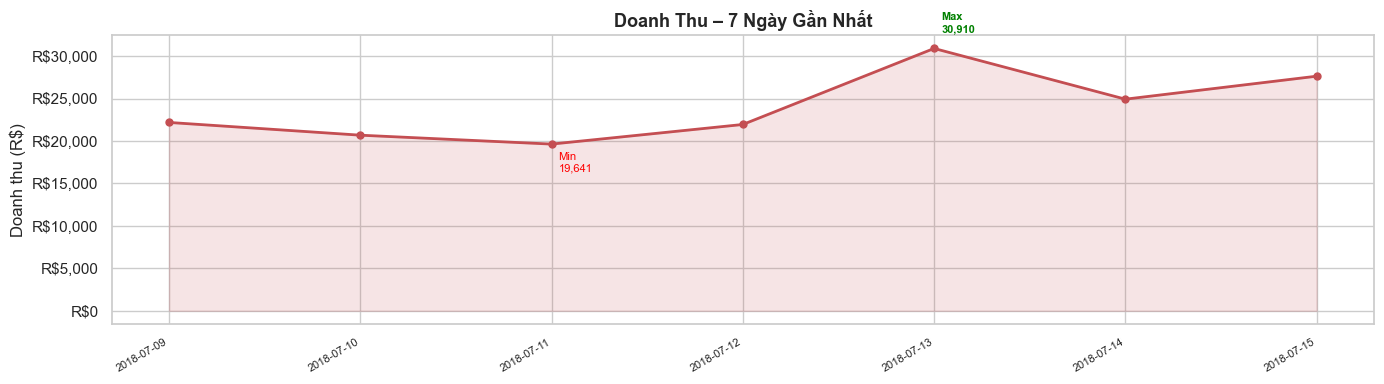

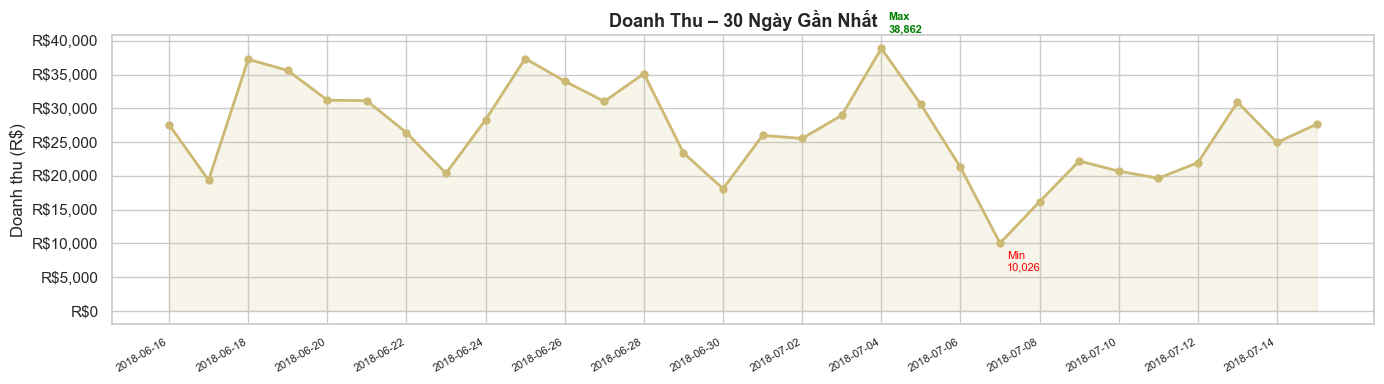

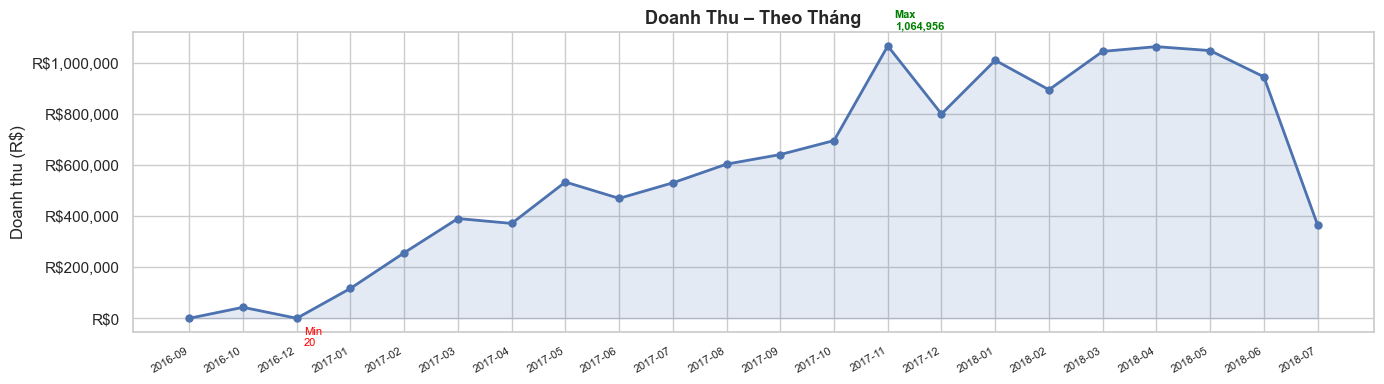

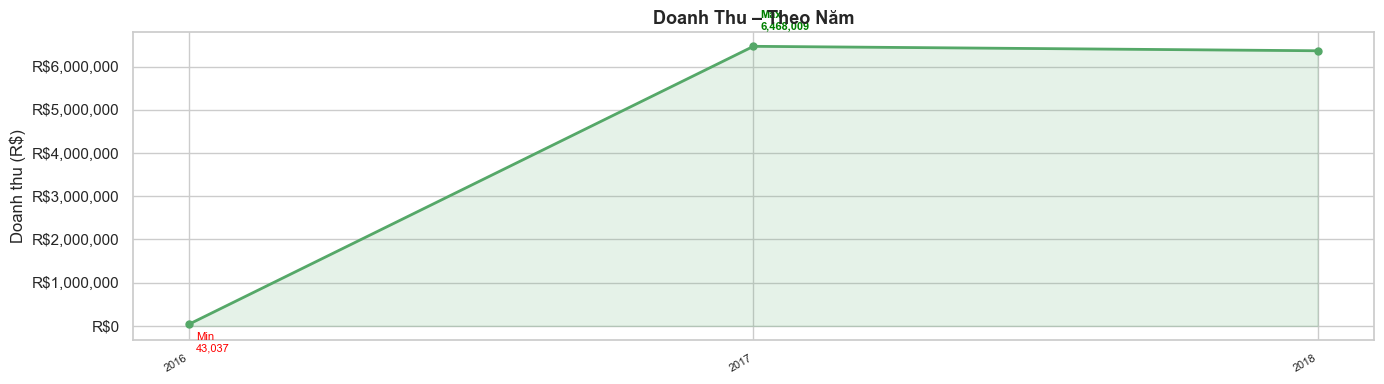

In [52]:
def plot_revenue_trend(data, date_col, rev_col, title, color=COLOR_PRIMARY, fmt_x=None):
    """Hàm tái sử dụng vẽ line chart doanh thu."""
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(data[date_col].astype(str), data[rev_col], alpha=0.15, color=color)
    ax.plot(data[date_col].astype(str), data[rev_col], marker='o', markersize=5,
            color=color, linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Doanh thu (R$)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
    step = max(1, len(data) // 12)
    ax.set_xticks(range(0, len(data), step))
    ax.set_xticklabels(data[date_col].astype(str).iloc[::step], rotation=30, ha='right', fontsize=8)
    # Annotate min/max
    idx_max = data[rev_col].idxmax(); idx_min = data[rev_col].idxmin()
    ax.annotate(f"Max\n{data.loc[idx_max,rev_col]:,.0f}",
                xy=(data.index.get_loc(idx_max), data.loc[idx_max,rev_col]),
                xytext=(5, 12), textcoords='offset points', fontsize=8, color='green', fontweight='bold')
    ax.annotate(f"Min\n{data.loc[idx_min,rev_col]:,.0f}",
                xy=(data.index.get_loc(idx_min), data.loc[idx_min,rev_col]),
                xytext=(5,-20), textcoords='offset points', fontsize=8, color='red')
    plt.tight_layout()
    return fig

max_date = order_df['order_date'].max()
order_df['date']  = order_df['order_date'].dt.date
order_df['month'] = order_df['order_date'].dt.to_period('M').astype(str)
order_df['year']  = order_df['order_date'].dt.year

# ── 4a. 7 ngày gần nhất ───────────────────────────────────
cut_7d = max_date - pd.Timedelta(days=7)
rev_7d = order_df[order_df['order_date'] >= cut_7d].groupby('date')['revenue'].sum().reset_index()
fig = plot_revenue_trend(rev_7d, 'date', 'revenue', 'Doanh Thu – 7 Ngày Gần Nhất', COLOR_DANGER)
plt.show()

# ── 4b. 30 ngày gần nhất ──────────────────────────────────
cut_30d = max_date - pd.Timedelta(days=30)
rev_30d = order_df[order_df['order_date'] >= cut_30d].groupby('date')['revenue'].sum().reset_index()
fig = plot_revenue_trend(rev_30d, 'date', 'revenue', 'Doanh Thu – 30 Ngày Gần Nhất', COLOR_WARN)
plt.show()

# ── 4c. Theo tháng ────────────────────────────────────────
rev_month = order_df.groupby('month')['revenue'].sum().reset_index()
fig = plot_revenue_trend(rev_month, 'month', 'revenue', 'Doanh Thu – Theo Tháng', COLOR_PRIMARY)
plt.show()

# ── 4d. Theo năm ──────────────────────────────────────────
rev_year = order_df.groupby('year')['revenue'].sum().reset_index()
fig = plot_revenue_trend(rev_year, 'year', 'revenue', 'Doanh Thu – Theo Năm', COLOR_SUCCESS)
plt.show()

## 5. Top Danh Mục & Sản Phẩm

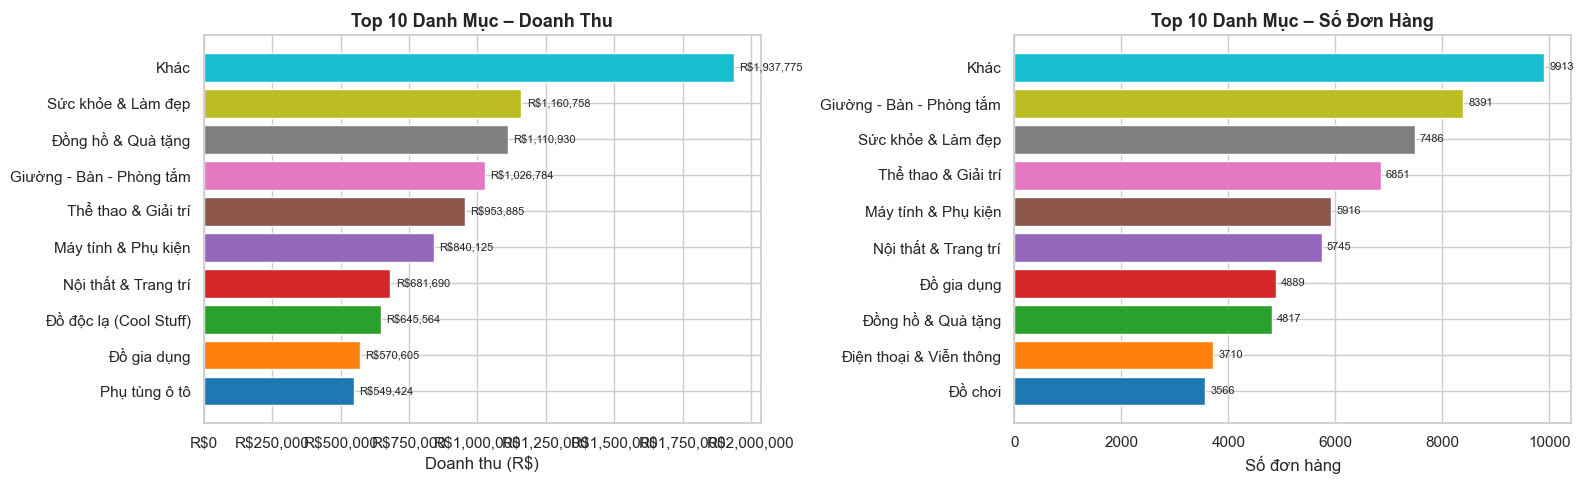

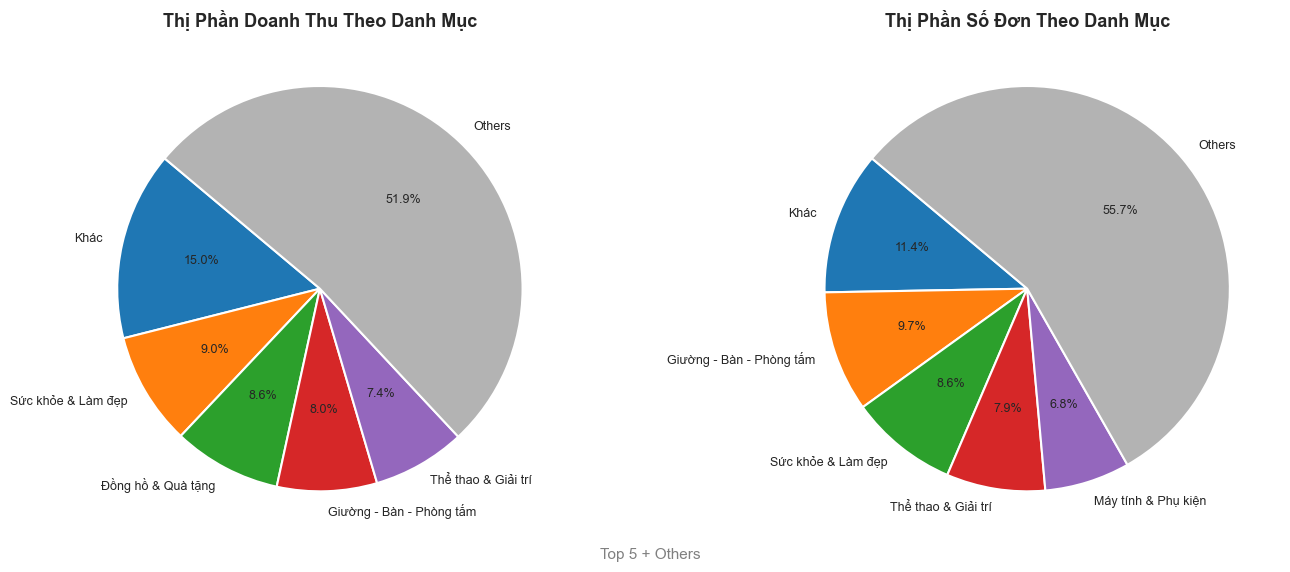

In [53]:
# ── Top 10 danh mục theo doanh thu & số đơn ─────────────
cat_rev = order_df.groupby('category')['revenue']                   .sum().sort_values(ascending=False).head(10).reset_index()
cat_rev.columns = ['category', 'revenue']

cat_cnt = df.groupby('Category_VN')['order_id']             .nunique().sort_values(ascending=False).head(10).reset_index()
cat_cnt.columns = ['category', 'orders']

palette10 = sns.color_palette('tab10', 10)

# ── Bar chart: doanh thu & số đơn ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].barh(cat_rev['category'][::-1], cat_rev['revenue'][::-1],
                    color=palette10, edgecolor='white')
axes[0].set_title('Top 10 Danh Mục – Doanh Thu', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Doanh thu (R$)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
for bar, val in zip(bars, cat_rev['revenue'][::-1]):
    axes[0].text(val + cat_rev['revenue'].max()*0.01, bar.get_y()+bar.get_height()/2,
                 f'R${val:,.0f}', va='center', fontsize=8)

bars2 = axes[1].barh(cat_cnt['category'][::-1], cat_cnt['orders'][::-1],
                     color=palette10, edgecolor='white')
axes[1].set_title('Top 10 Danh Mục – Số Đơn Hàng', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số đơn hàng')
for bar, val in zip(bars2, cat_cnt['orders'][::-1]):
    axes[1].text(val + cat_cnt['orders'].max()*0.01, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── Pie chart: thị phần doanh thu top 5 + Others ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Doanh thu
all_cat_rev = order_df.groupby('category')['revenue'].sum().sort_values(ascending=False)
top5_rev    = all_cat_rev.head(5)
others_rev  = all_cat_rev.iloc[5:].sum()
pie_rev     = pd.concat([top5_rev, pd.Series({'Others': others_rev})])

colors6 = sns.color_palette('tab10', 5) + [(0.7, 0.7, 0.7)]
axes[0].pie(pie_rev.values, labels=pie_rev.index,
            autopct='%1.1f%%', colors=colors6,
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5},
            textprops={'fontsize':9})
axes[0].set_title('Thị Phần Doanh Thu Theo Danh Mục', fontsize=13, fontweight='bold')

# Số đơn
all_cat_cnt = df.groupby('Category_VN')['order_id'].nunique().sort_values(ascending=False)
top5_cnt    = all_cat_cnt.head(5)
others_cnt  = all_cat_cnt.iloc[5:].sum()
pie_cnt     = pd.concat([top5_cnt, pd.Series({'Others': others_cnt})])

axes[1].pie(pie_cnt.values, labels=pie_cnt.index,
            autopct='%1.1f%%', colors=colors6,
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5},
            textprops={'fontsize':9})
axes[1].set_title('Thị Phần Số Đơn Theo Danh Mục', fontsize=13, fontweight='bold')

plt.suptitle('Top 5 + Others', fontsize=11, color='gray', y=0.02)
plt.tight_layout()
plt.show()

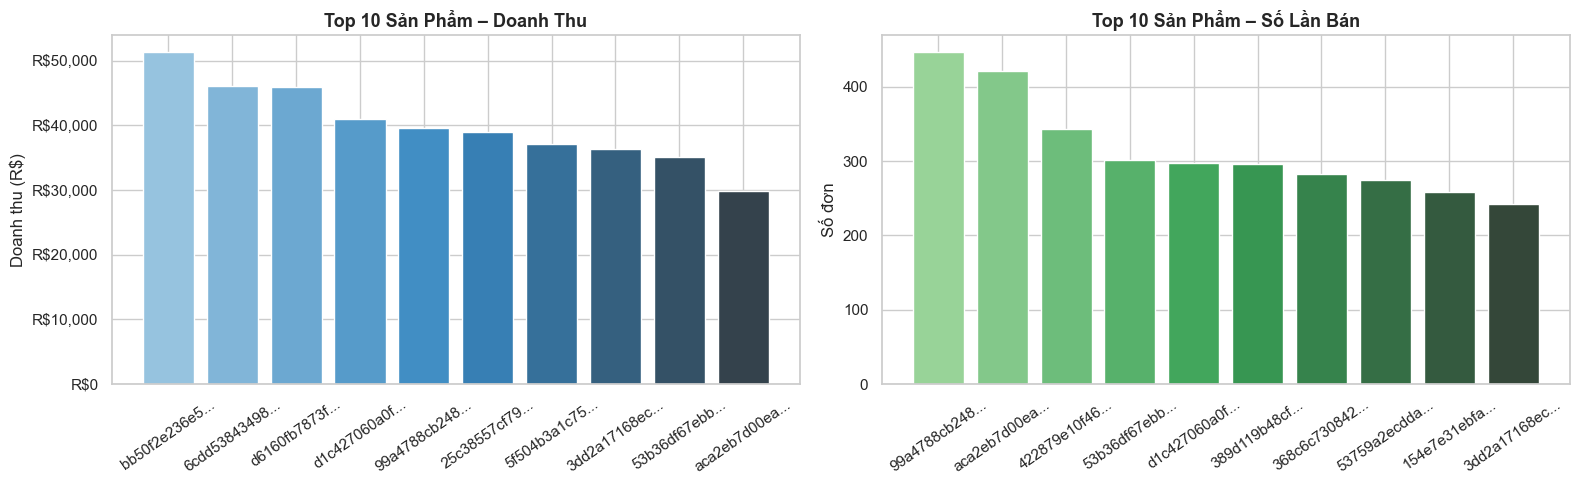

In [54]:
# ── Top 10 sản phẩm theo doanh thu ──────────────────────
prod_rev = df.groupby('product_id').agg(
    revenue = ('price', 'sum')   # dùng price per item vì product trải trên nhiều đơn
).sort_values('revenue', ascending=False).head(10).reset_index()
prod_rev['product_short'] = prod_rev['product_id'].str[:12] + '...'

prod_cnt = df.groupby('product_id')['order_id']              .nunique().sort_values(ascending=False).head(10).reset_index()
prod_cnt['product_short'] = prod_cnt['product_id'].str[:12] + '...'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(prod_rev['product_short'], prod_rev['revenue'],
            color=sns.color_palette('Blues_d', 10), edgecolor='white')
axes[0].set_title('Top 10 Sản Phẩm – Doanh Thu', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Doanh thu (R$)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))

axes[1].bar(prod_cnt['product_short'], prod_cnt['order_id'],
            color=sns.color_palette('Greens_d', 10), edgecolor='white')
axes[1].set_title('Top 10 Sản Phẩm – Số Lần Bán', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số đơn')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

## 6. Phân Tích Địa Lý – Top 10

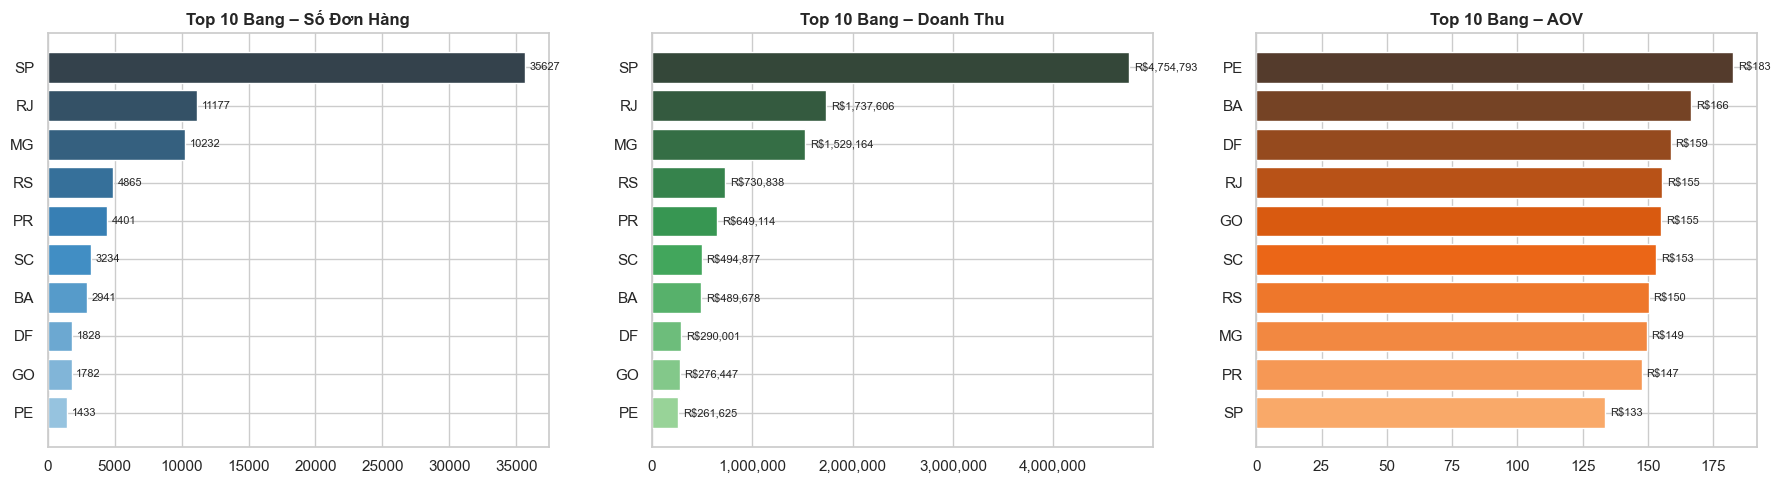

In [55]:
# ── Top 10 bang ──────────────────────────────────────────
state_stats = order_df.groupby('state').agg(
    so_don   = ('order_id', 'count'),
    doanh_thu= ('revenue',  'sum'),
    aov      = ('revenue',  'mean')
).sort_values('doanh_thu', ascending=False).head(10).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pal_blue  = sns.color_palette('Blues_d',  10)
pal_green = sns.color_palette('Greens_d', 10)
pal_oran  = sns.color_palette('Oranges_d',10)

for ax, col, title, pal, fmt in zip(
    axes,
    ['so_don','doanh_thu','aov'],
    ['Số Đơn Hàng','Doanh Thu','AOV'],
    [pal_blue, pal_green, pal_oran],
    [False, True, True]
):
    s = state_stats.sort_values(col)
    bars = ax.barh(s.index, s[col], color=pal, edgecolor='white')
    ax.set_title(f'Top 10 Bang – {title}', fontsize=12, fontweight='bold')
    if fmt:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    for bar, val in zip(bars, s[col]):
        lbl = f'R${val:,.0f}' if fmt else str(int(val))
        ax.text(val + s[col].max()*0.01, bar.get_y()+bar.get_height()/2,
                lbl, va='center', fontsize=8)

plt.tight_layout()
plt.show()

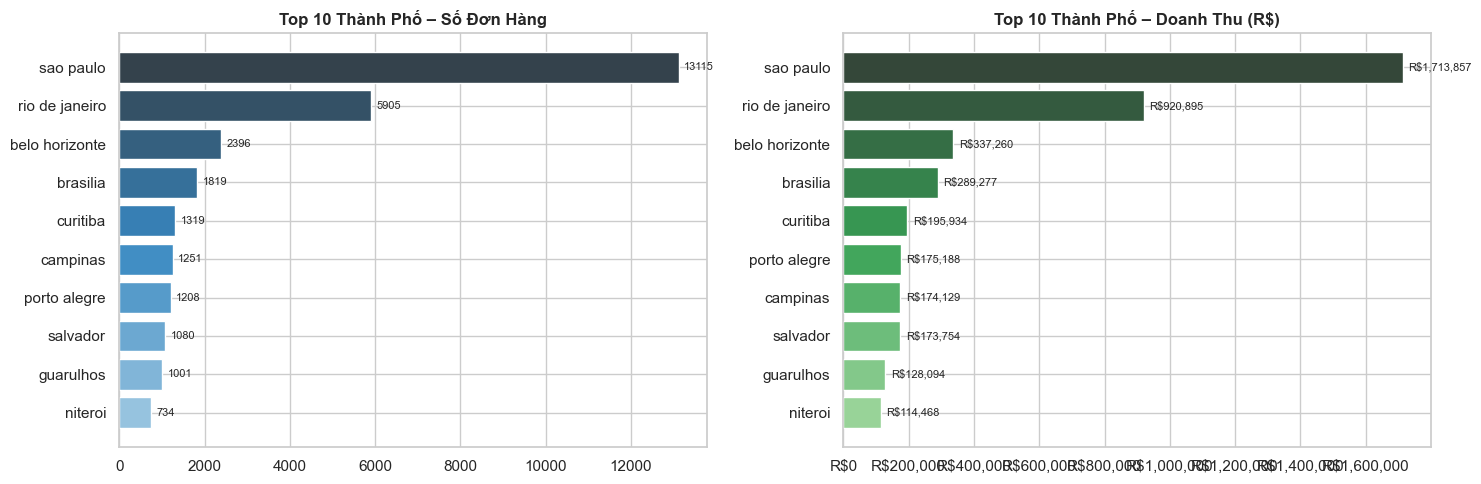

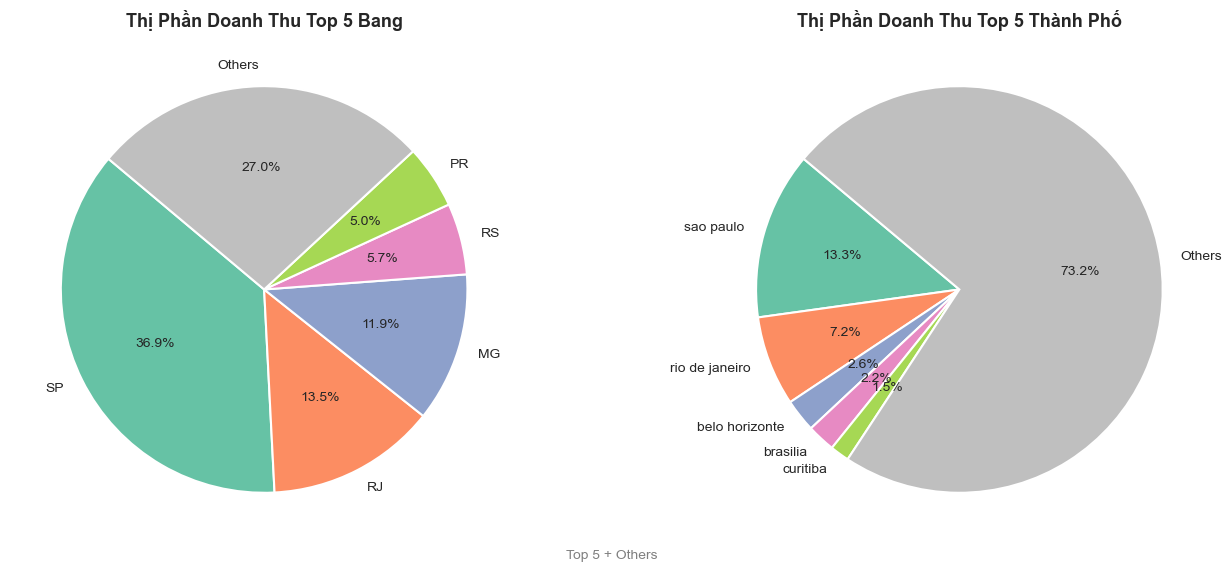

In [56]:
# ── Top 10 thành phố ─────────────────────────────────────
city_stats = order_df.groupby('city').agg(
    so_don    = ('order_id', 'count'),
    doanh_thu = ('revenue',  'sum')
).sort_values('doanh_thu', ascending=False).head(10).round(2)

pal_blue  = sns.color_palette('Blues_d',  10)
pal_green = sns.color_palette('Greens_d', 10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, title, pal, fmt in zip(
    axes,
    ['so_don','doanh_thu'],
    ['Số Đơn Hàng','Doanh Thu (R$)'],
    [pal_blue, pal_green],
    [False, True]
):
    s = city_stats.sort_values(col)
    bars = ax.barh(s.index, s[col], color=pal, edgecolor='white')
    ax.set_title(f'Top 10 Thành Phố – {title}', fontsize=12, fontweight='bold')
    if fmt:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
    for bar, val in zip(bars, s[col]):
        lbl = f'R${val:,.0f}' if fmt else str(int(val))
        ax.text(val + s[col].max()*0.01, bar.get_y()+bar.get_height()/2,
                lbl, va='center', fontsize=8)
plt.tight_layout()
plt.show()

# ── Pie chart: thị phần doanh thu top 5 bang + Others ────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

all_state = order_df.groupby('state')['revenue'].sum().sort_values(ascending=False)
top5_state = all_state.head(5)
pie_state  = pd.concat([top5_state, pd.Series({'Others': all_state.iloc[5:].sum()})])

colors6 = sns.color_palette('Set2', 5) + [(0.75, 0.75, 0.75)]
axes[0].pie(pie_state.values, labels=pie_state.index,
            autopct='%1.1f%%', colors=colors6, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5},
            textprops={'fontsize':10})
axes[0].set_title('Thị Phần Doanh Thu Top 5 Bang', fontsize=13, fontweight='bold')

all_city = order_df.groupby('city')['revenue'].sum().sort_values(ascending=False)
top5_city = all_city.head(5)
pie_city  = pd.concat([top5_city, pd.Series({'Others': all_city.iloc[5:].sum()})])

axes[1].pie(pie_city.values, labels=pie_city.index,
            autopct='%1.1f%%', colors=colors6, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5},
            textprops={'fontsize':10})
axes[1].set_title('Thị Phần Doanh Thu Top 5 Thành Phố', fontsize=13, fontweight='bold')

plt.suptitle('Top 5 + Others', fontsize=10, color='gray', y=0.02)
plt.tight_layout()
plt.show()

## 7. Hiệu Suất Seller

Tong sellers: 2,693
            sid  doanh_thu  so_don     aov
1   4869F7A5...  220460.66     993  222.01
2   4A3CA931...  210241.93    1632  128.82
3   53243585...  195401.36     270  723.71
4   FA1C13F2...  182992.65     518  353.27
5   7C67E144...  174332.93     936  186.25
6   7E93A43E...  170311.37     316  538.96
7   DA8622B1...  159693.48    1192  133.97
8   7A67C85E...  157574.94    1103  142.86
9   46DC3B2C...  130268.08     495  263.17
10  955FEE92...  122814.81    1150  106.80


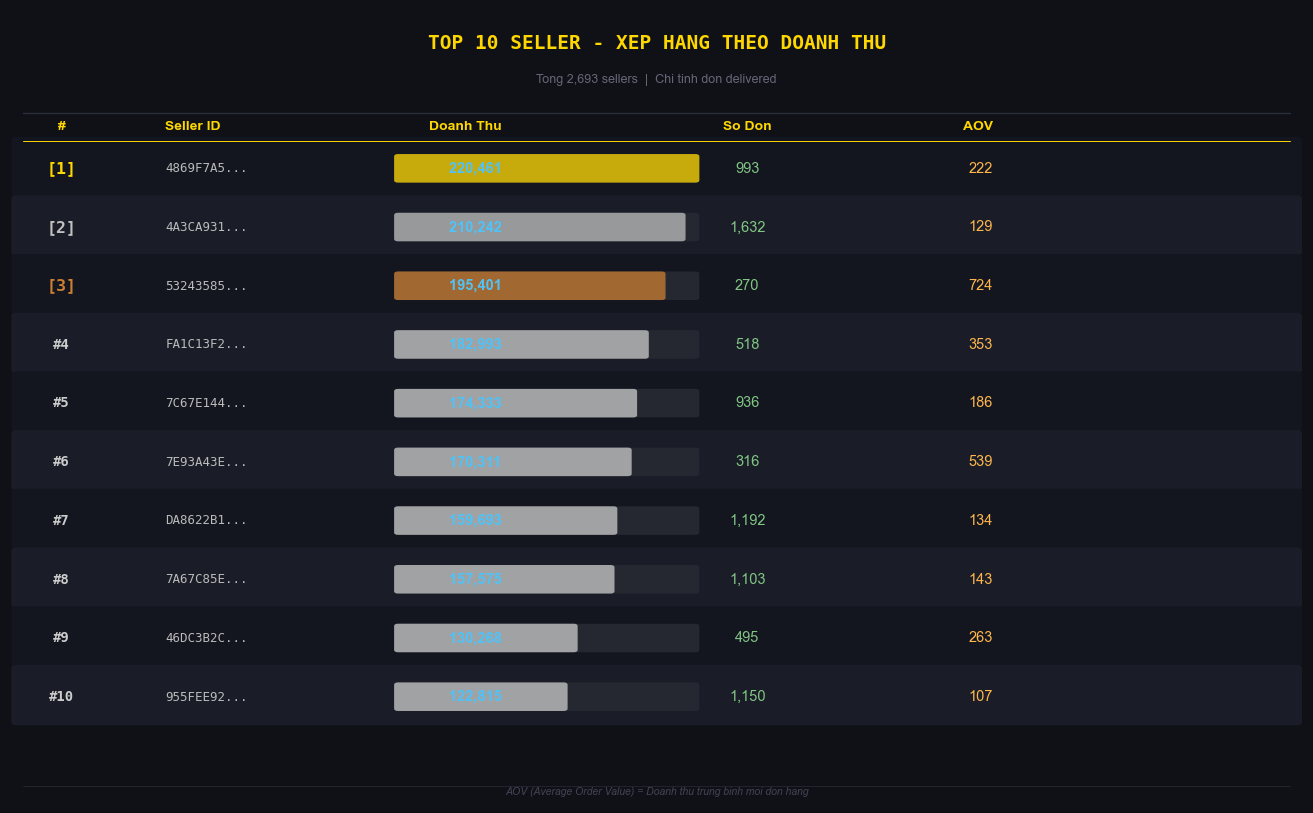

In [60]:

# ── Tổng hợp theo seller ──────────────────────────────────
order_df['order_date'] = pd.to_datetime(order_df['order_date'])

seller_stats = order_df.groupby('seller_id').agg(
    so_don    = ('order_id', 'count'),
    doanh_thu = ('revenue',  'sum'),
    aov       = ('revenue',  'mean'),
).round(2).reset_index()

# Xếp hạng theo doanh thu
sellerT10 = seller_stats.sort_values('doanh_thu', ascending=False).head(10).reset_index(drop=True)
sellerT10.index += 1
sellerT10['sid'] = sellerT10['seller_id'].str[:8].str.upper() + '...'

print(f"Tong sellers: {len(seller_stats):,}")
print(sellerT10[['sid','doanh_thu','so_don','aov']].to_string())

# ── Ve bang ───────────────────────────────────────────────
BG = '#0F1117'
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')

# Title
ax.text(0.5, 0.97, 'TOP 10 SELLER - XEP HANG THEO DOANH THU',
        ha='center', va='top', fontsize=14, fontweight='bold',
        color='#FFD700', fontfamily='monospace')
ax.text(0.5, 0.92,
        f'Tong {len(seller_stats):,} sellers  |  Chi tinh don delivered',
        ha='center', va='top', fontsize=9, color='#666677')

# Header
cols   = ['#',        'Seller ID', 'Doanh Thu', 'So Don', 'AOV']
col_x  = [0.04,       0.12,         0.38,            0.57,     0.76     ]
col_al = ['center',  'left',       'right',          'center', 'right'  ]
rank_labels = {1:'[1]',2:'[2]',3:'[3]',4:'#4',5:'#5',
               6:'#6', 7:'#7', 8:'#8', 9:'#9',10:'#10'}

ax.plot([0.01,0.99],[0.870,0.870], color='#2A2D3A', linewidth=1)
for cx,c,al in zip(col_x, cols, col_al):
    ax.text(cx, 0.853, c, ha=al, va='center', fontsize=10,
            fontweight='bold', color='#FFD700')
ax.plot([0.01,0.99],[0.835,0.835], color='#FFD700', linewidth=0.7)

medal  = {1:'#FFD700', 2:'#C0C0C0', 3:'#CD7F32'}
max_dt = sellerT10['doanh_thu'].max()
ROW_H  = 0.074; START_Y = 0.800

for i, row in sellerT10.iterrows():
    y = START_Y - (i-1) * ROW_H

    # Row background
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.005, y-0.032), 0.99, ROW_H-0.006, boxstyle='round,pad=0.004',
        facecolor='#1A1D27' if i%2==0 else '#13151F', edgecolor='none'))

    rc = medal.get(i, '#CCCCCC')

    # Rank
    ax.text(col_x[0], y, rank_labels[i], ha='center', va='center',
            fontsize=12 if i<=3 else 10, color=rc,
            fontweight='bold', fontfamily='monospace')

    # Seller ID
    ax.text(col_x[1], y, row['sid'], ha='left', va='center',
            fontsize=9, color='#BBBBBB', fontfamily='monospace')

    # Doanh thu + mini bar
    bar_x, bar_w_max = 0.30, 0.23
    bar_w = bar_w_max * (row['doanh_thu'] / max_dt)
    ax.add_patch(mpatches.FancyBboxPatch(
        (bar_x, y-0.015), bar_w_max, 0.030, boxstyle='round,pad=0.003',
        facecolor='#252830', edgecolor='none'))
    ax.add_patch(mpatches.FancyBboxPatch(
        (bar_x, y-0.015), max(bar_w, 0.004), 0.030, boxstyle='round,pad=0.003',
        facecolor=rc, edgecolor='none', alpha=0.75))
    ax.text(col_x[2], y, f"{row['doanh_thu']:>10,.0f}", ha='right', va='center',
            fontsize=10.5, color='#4FC3F7', fontweight='bold')

    # So don
    ax.text(col_x[3], y, f"{int(row['so_don']):,}", ha='center', va='center',
            fontsize=10.5, color='#81C784')

    # AOV
    ax.text(col_x[4], y, f"{row['aov']:,.0f}", ha='right', va='center',
            fontsize=10.5, color='#FFB74D')

# Footer line
ax.plot([0.01,0.99],[0.022,0.022], color='#2A2D3A', linewidth=0.5)
ax.text(0.5, 0.008,
        'AOV (Average Order Value) = Doanh thu trung binh moi don hang',
        ha='center', va='bottom', fontsize=7.5, color='#444455', style='italic')

plt.tight_layout(pad=0.2)
plt.show()

## 8. 🔥 Heatmap Hành Vi Mua Sắm (Giờ × Thứ)

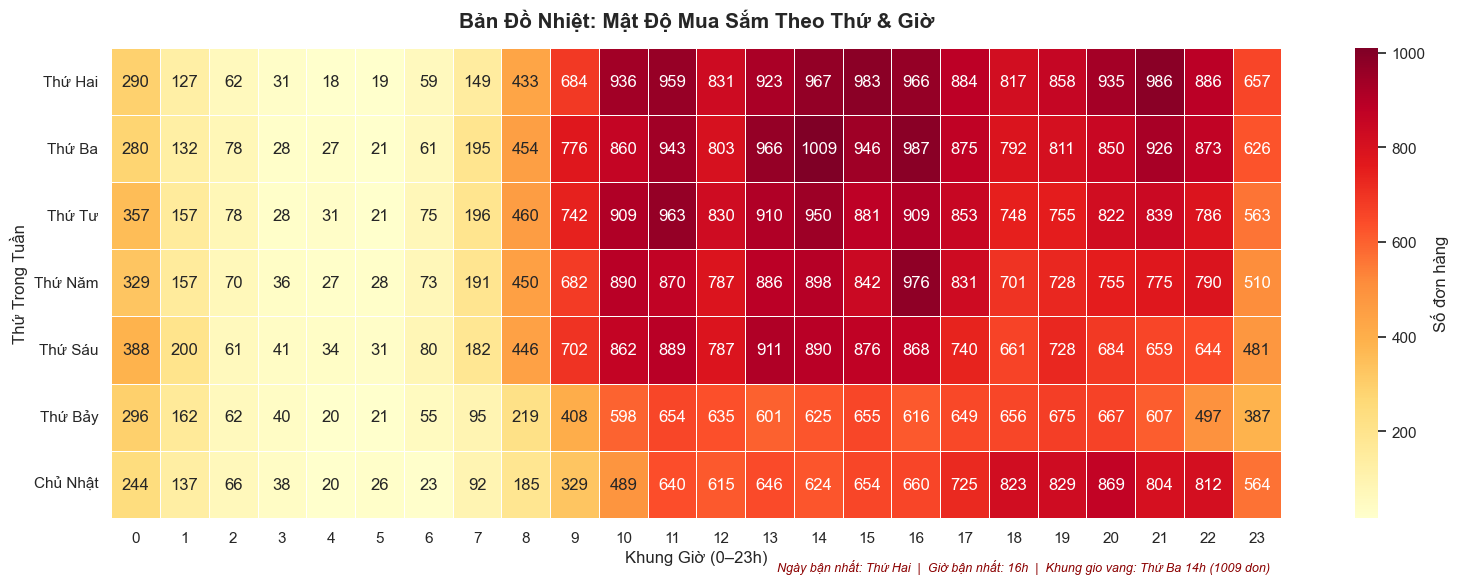

Ngày bận nhất (tổng): Thứ Hai
Giờ bận nhất  (tổng): 16h
Ô cao nhất thực sự  : Thứ Ba – 14h (1009 đơn)


In [58]:
# ── Chuẩn bị dữ liệu ────────────────────────────────────
df_time = df.copy()
df_time['Hour']    = df_time['order_purchase_timestamp'].dt.hour
df_time['Weekday'] = df_time['order_purchase_timestamp'].dt.day_name()

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
days_vn    = {'Monday':'Thứ Hai','Tuesday':'Thứ Ba','Wednesday':'Thứ Tư',
              'Thursday':'Thứ Năm','Friday':'Thứ Sáu','Saturday':'Thứ Bảy','Sunday':'Chủ Nhật'}
df_time['Weekday'] = pd.Categorical(df_time['Weekday'], categories=days_order, ordered=True)

heatmap_data = df_time.groupby(['Weekday','Hour'])['order_id'].count().unstack(fill_value=0)
heatmap_data.index = [days_vn[d] for d in heatmap_data.index]

# ── Vẽ biểu đồ ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.4, annot=True, fmt='.0f',
            ax=ax, cbar_kws={'label': 'Số đơn hàng'})
ax.set_title('Bản Đồ Nhiệt: Mật Độ Mua Sắm Theo Thứ & Giờ',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Khung Giờ (0–23h)', fontsize=12)
ax.set_ylabel('Thứ Trong Tuần', fontsize=12)
ax.tick_params(axis='y', rotation=0)

# ── Annotation: ngày bận nhất, giờ bận nhất, ô max thực sự ──
peak_day      = heatmap_data.sum(axis=1).idxmax()   # ngày có tổng cao nhất
peak_hour     = heatmap_data.sum(axis=0).idxmax()   # giờ có tổng cao nhất
max_pos       = heatmap_data.stack().idxmax()        # ô (ngày, giờ) cao nhất
max_val       = heatmap_data.stack().max()

ax.text(0.99, -0.12,
        f'Ngày bận nhất: {peak_day}  |  Giờ bận nhất: {peak_hour}h  |  '
        f'Khung gio vang: {max_pos[0]} {max_pos[1]}h ({max_val:.0f} don)',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='darkred', fontstyle='italic')

plt.tight_layout()
plt.show()
print(f"Ngày bận nhất (tổng): {peak_day}")
print(f"Giờ bận nhất  (tổng): {peak_hour}h")
print(f"Ô cao nhất thực sự  : {max_pos[0]} – {max_pos[1]}h ({max_val:.0f} đơn)")

In [59]:
print("=" * 60)
print("TONG KET EDA")
print("=" * 60)
print(f"  Delivered orders  : {total_orders:,}")
print(f"  Tong doanh thu    : R$ {total_revenue:,.2f}")
print(f"  AOV               : R$ {avg_order_val:,.2f}")
print(f"  Khach hang unique : {total_customers:,}")
print(f"  Sellers           : {total_sellers:,}")
top_cat   = order_df.groupby('category')['revenue'].sum().idxmax()
top_state = order_df.groupby('state')['revenue'].sum().idxmax()
print(f"  Danh muc #1       : {top_cat}")
print(f"  Bang #1           : {top_state}")
print(f"  Ngay ban nhat     : {peak_day}")
print(f"  Gio ban nhat      : {peak_hour}h")
print(f"  Khung gio vang    : {max_pos[0]} – {max_pos[1]}h ({max_val:.0f} don)")
print("=" * 60)

TONG KET EDA
  Delivered orders  : 86,277
  Tong doanh thu    : R$ 12,876,192.20
  AOV               : R$ 149.24
  Khach hang unique : 83,506
  Sellers           : 2,705
  Danh muc #1       : Khác
  Bang #1           : SP
  Ngay ban nhat     : Thứ Hai
  Gio ban nhat      : 16h
  Khung gio vang    : Thứ Ba – 14h (1009 don)
